In [1]:
!pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 132.7 MB/s eta 0:00:00

In [1]:
# 기본 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras

import random
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  tf.config.experimental.enable_op_determinism()

In [2]:
tf.__version__

# 이번 예제는 2.12.x 으로 하겠습니다.

'2.12.0'

# 트랜스포머 (Transformer)
* 2017년 구글브레인 이 발표한 논문인 **"Attention is all you need"** 에서 나온 모델
  - 논문링크 : https://proceedings.neurips.cc/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf
* 트랜스포머는 <u>RNN을 사용하지 않고</u> '인코더'와 '디코더'를 설계하였으며, 성능도 RNN보다 우수함
  - 처음에는 자연어 처리 분야에서만 사용되었으나 이후 컴퓨터 비전 분야까지 확장됐으며 현재는 다양한 분야에서 채택되고 있다.

* 기존의 seq2seq의 구조인 인코더-디코더를 따르면서도, 논문의 이름처럼 어텐션(Attention)만으로 구현한 모델

* 이후 등장한 BERT, GPT, AlphaFold 2 등이 Transformer 기반으로 만들어졌다.

![](https://i.namu.wiki/i/Og6EWpFFi7q01asl6LEay_-VVe9Vpedia1t2IAEXShjv2t_T2bzUdRMYa98XSfv6W_7S0_TWn9Ksncy6g6bCZM4zXS1I7QvfQO4xx9ke0yo1W8d6oYkicOKdv8XMlf_SUM_xGN3NnqYUvpYSz7nT0Q.webp)



# 1. 기존의 seq2seq 모델의 한계

![](https://wikidocs.net/images/page/24996/%EC%9D%B8%EC%BD%94%EB%8D%94%EB%94%94%EC%BD%94%EB%8D%94%EB%AA%A8%EB%8D%B8.PNG)

- 기존의 Seq2Seq 는 인코더-디코더 구조로 구성 되었다
  - 인코더는 입력 시퀀스를 하나의 벡터 표현으로 압축하고
  - 디코더는 이 벡터 표현을 통해서 출력 시퀀스를 만들어냈다
- 단점!
  - 인코더가 입력 시퀀스를 하나의 벡터로 압축하는 과정에서
입력 시퀀스의 정보가 일부 손실된다는 단점. (Vanishing Gradient)
  - 이를 보정하기 위해 '어텐션'이 사용되었었다.
  
- 트랜스포머의 아이디어!
  - **'어텐션'** 을 RNN 보정을 위한 용도로 사용하는 것이 아니라 **어텐션만으로 인코더와 디코더를** 만들어보면 어떨까?



# 2. 트랜스포머(Transformer)의 주요 하이퍼파라미터

- 트랜스포머 논문에서 설정된 하이퍼 파라미터 값들.
  - 사용자가 모델 설계시 변경할수 도 있는 값들.
- 의미에 대해서는 뒤에서 설명예정

---
$$d_{model} = 512$$
<br>
- 인코더와 디코더에서의 정해진 입력과 출력의 크기
- 임베딩 벡터의 차원 또한 $d_{model}$
- 인코더와 디코더가 다음 층의 인코더와 디코더로 값을 보낼 때에도 이 차원을 유지.
- 논문에서는 512입니다

---
$$\text{num_layers} = 6$$

- 트랜스포머에서 하나의 **인코더와 디코더를 '층(layer)'**으로 생각할수 있다.
- 트랜스포머 모델에서 **인코더와 디코더가 총 몇개의 '층'**으로 구성되었는지를 의미.
- 논문에서는 인코더와 디코더를 각각 총 6개 쌓았다.


---
$$\text{num_heads} = 8$$

- 트랜스포머에서는 어텐션을 사용할 때, 한 번 하는 것 보다 여러 개로 분할해서 **병렬로 어텐션을 수행**하고
- 그 결과값을 다시 하나로 합치는 방식을 사용한다.
- $\text{num_heads}$ 값은 그 **병렬의 개수**를 의미합니다.
---
$$d_{ff} = 2048$$

- 트랜스포머 내부에는 피드 포워드 신경망이 존재하며
- $d_{ff}$는 해당 신경망의 은닉층의 크기다.
- 피드 포워드 신경망의 입력층과 출력층의 크기는 $d_{model}$
입니다.

# 트랜스포머

![](https://wikidocs.net/images/page/31379/transformer1.PNG)

- 트랜스포머는 RNN을 사용하지 않지만,
- 기존의 seq2seq처럼 **인코더-디코더 구조**를 유지한다
  - 인코더에서 입력 시퀀스를 입력
  - 디코더에서 출력 시퀀스를 출력
- 이전 seq2seq 구조에서는 인코더와 디코더에서 각각 하나의 RNN이 t개의 시점(time step)을 가지는 구조였다면,
- 트랜스포머에서는 **인코더와 디코더라는 단위가 N개로 구성되는 구조**.

- 논문에서는 인코더와 디코더의 개수를 각각 6개 사용.

---
![](https://wikidocs.net/images/page/31379/transformer2.PNG)
- 위의 그림은 인코더와 디코더가 6개씩 존재하는 트랜스포머의 구조를 보여줍니다.
- ※ 인코더와 디코더가 각각 여러 개 쌓여있다는 의미를 사용할 때는 알파벳 s를 뒤에 붙여 encoders, decoders라고 표현하겠습니다.

---
![](https://wikidocs.net/images/page/31379/transformer4_final_final_final.PNG)
- 위의 그림은 인코더로부터 정보를 전달받아 디코더가 출력 결과를 만들어내는 트랜스포머 구조.
- **디코더**는
  - 마치 기존의 seq2seq 구조처럼 시작 심볼 &lt;sos&gt; 를 입력으로 받아
  - 종료 심볼 &lt;eos&gt;가 나올 때까지 연산을 진행합니다.
  - 이는 RNN은 사용되지 않지만 여전히 인코더-디코더의 구조는 유지되고 있음을 보여준다.

- **트랜스포머의 입력**
  - 트랜스포머의 인코더와 디코더는 단순히 각 단어의 임베딩 벡터들을 입력받는 것이 아니라
  - **임베딩 벡터에서 '조정된 값'을 입력**받는다

# 포지셔널 인코딩 (Positional Encoding)

- RNN 이 자연어 처리에서 유용했던 이유는?
  - 단어의 위치에 따라 단어를 순차적으로 입력받아서 처리하는 RNN의 특성으로 인해
  - 각 단어의 **위치 정보(position information)**를 가질 수 있다는 점!!  

- 하지만 트랜스포머는 단어 입력을 순차적으로 받는 방식이 아니므로,
  - 단어의 위치 정보를 다른 방식으로 알려줄 필요가 있다!
- 트랜스포머는 단어의 위치 정보를 얻기 위해서
  - 각 단어의 **'임베딩 벡터'** 에 **'위치 정보'**들을 더하여 모델의 입력으로 사용하는데,
  - 이를 **포지셔널 인코딩(positional encoding)**이라고 합니다.

![](https://wikidocs.net/images/page/31379/transformer5_final_final.PNG)
- ↑ 위 그림은 입력으로 사용되는 임베딩 벡터들이 트랜스포머의 입력으로 사용되기 전에 포지셔널 인코딩의 값이 더해지는 것을 보여줍니다.


- 임베딩 벡터가 인코더의 입력으로 사용되기 전 포지셔널 인코딩값이 더해지는 과정을 시각화하면 아래와 같습니다.
![](https://wikidocs.net/images/page/31379/transformer6_final.PNG)

- 포지셔널 인코딩 값들은 어떤 값이기에 '위치 정보'를 반영해줄 수 있는 것일까요? 트랜스포머는 위치 정보를 가진 값을 만들기 위해서 아래의 두 개의 함수를 사용합니다.

$$PE_{(pos, 2i)} = sin(pos/10000^{2i/d_{model}})$$

$$PE_{(pos, 2i+1)} = cos(pos/10000^{2i/d_{model}})$$

- 사인 함수와 코사인 함수의 그래프를 상기해보면 요동치는 값의 형태를 생각해볼 수 있다.
- 트랜스포머는 사인 함수와 코사인 함수의 값을 임베딩 벡터에 더해주므로서 단어의 '순서 정보'를 더하여 준다

- 그런데 위의 두 함수에는 $pos$, $i$, $d_{model}$ 등의 생소한 변수들이 있습니다.
- 위의 함수를 이해하기 위해서는 위에서 본 임베딩 벡터와 포지셔널 인코딩의 덧셈은 사실 **임베딩 벡터가 모여 만들어진 문장 행렬** 과 **포지셔널 인코딩 행렬**의 덧셈 연산을 통해 이루어진다는 점을 이해해야 합니다.

![](https://wikidocs.net/images/page/31379/transformer7.PNG)

- $pos$ 는 입력 문장에서의 **임베딩 벡터의 위치**,
- $i$ 는 임베딩 벡터 내의 **차원의 인덱스**.
- 위의 식에 따르면 임베딩 벡터 내의 각 차원의 인덱스 $i$ 가
  - 짝수인 경우에는 사인 함수의 값을 사용
  - 홀수인 경우에는 코사인 함수의 값을 사용
- 즉! 위의 수식에서
  - $(pos, 2i)$ 일 때는 사인 함수를 사용!
  - $(pos, 2i+1)$일 때는 코사인 함수를 사용!

- 위의 식에서 $d_{model}$
은 트랜스포머의 **모든 층의 출력 차원**을 의미하는 트랜스포머의 하이퍼파라미터 라고 했습니다.

- 앞으로 보게 될 트랜스포머의 각종 구조에서
$d_{model}$ 값이 계속해서 등장하는 이유입니다.

- 임베딩 벡터 또한 $d_{model}$의 차원을 가지는데 위의 그림에서는 4로 표현되었지만 실제 논문에서는 512의 값을 가집니다.

- 위와 같은 포지셔널 인코딩 방법을 사용하면 **순서 정보**가 보존된다
- 예를 들어 각 임베딩 벡터에 포지셔널 인코딩의 값을 더하면 '같은 단어'라고 하더라도 '문장 내의 위치'에 따라서 트랜스포머의 입력으로 들어가는 임베딩 벡터의 값이 달라진다.
- 이에 따라 **트랜스포머의 입력**은 **순서 정보가 고려된 임베딩 벡터**가 됩니다.

## 🍎PositionalEncoding 구현

In [3]:
# keras 에선
#   Model 을 상속받아 커스텀 Model을 정의할수 있고
#   Layer 를 상속받아 커스턴 Layer를 정의할수도 있다.

In [4]:
class PositionalEncoding(tf.keras.layers.Layer):
  def __init__(self, position, d_model):
    super(PositionalEncoding, self).__init__()
    self.pos_encoding = self.positional_encoding(position, d_model)

  # sin, cos 에 넘겨줄 각도 (radian)
  def get_angles(self, position, i, d_model):
    angles = 1 / tf.pow(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    return position * angles

  def positional_encoding(self, position, d_model):
    # position, d_model => angle
    angle_rads = self.get_angles(
        position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],  # shape: (position, 1)
        i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],   # shape: (1, d_model)
        d_model=d_model)
        # angle_rads 는 get_angle() 내에서 (position, 1) * (1, d_model) => (position, d_model) 형태결과(브로드 캐스팅) 리턴받음
        # 만약 position=50, d_model=512 라면 angle_rads 의 shape 는 (50, 512)
        # 각 원소는 특정 위치 (position) 와 차원 인텍스(i) 에 대한 파형(주파수?) 기반의 라디언값이 되는겁니다.

    # 배열의 짝수 인덱스(2i)에는 사인 함수 적용
    sines = tf.math.sin(angle_rads[:, 0::2])

    # 배열의 홀수 인덱스(2i+1)에는 코사인 함수 적용
    cosines = tf.math.cos(angle_rads[:, 1::2])

    # angle_rads 를 sin 과 cos 값으로 채움.
    angle_rads = np.zeros(angle_rads.shape)
    angle_rads[:, 0::2] = sines
    angle_rads[:, 1::2] = cosines


    pos_encoding = tf.constant(angle_rads)
    pos_encoding = pos_encoding[tf.newaxis, ...]

    print(pos_encoding.shape)
    return tf.cast(pos_encoding, tf.float32)

  def call(self, inputs):
    return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


In [5]:
# 동작 확인
#   50 x 128 크기를 가지는 포지셔널 인코딩 행렬 시각화.
#   문장의 단어가 50개 (d_model),  각 단어의 표현은 128개 (<- 사전크키) 임베딩 벡터.

(1, 50, 128)


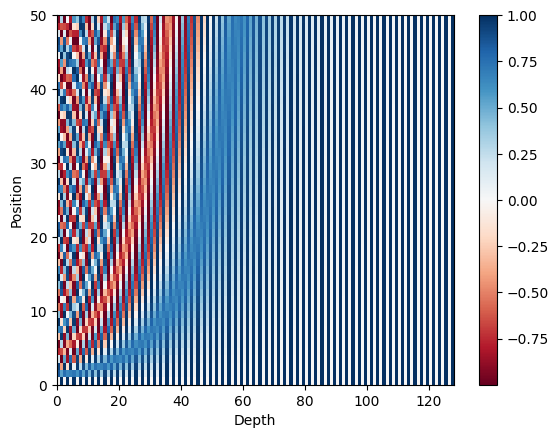

In [6]:
sample_pos_encoding = PositionalEncoding(50, 128)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 128))
plt.ylabel('Position')
plt.colorbar()
plt.show()



# 어텐션 (Attention) 세가지

![](https://wikidocs.net/images/page/31379/attention.PNG)

- **Encoder Self-Attention** 는 '인코더'에서 이루어진다
- **Masked Decoder Self-Attention** 과 **Encoder-Decoder Attention**은 '디코더'에서 이루어진다
- **XXX Self-Attention** 은 본질적으로 Query, Key, Value 가 '동일'한 출처인 경우를 말합니다.
  - 여기서 '동일' 하다는 뜻은 벡터의 값이 같다는 뜻이 아니라, **벡터의 출처가 같다는 의미**!
- 반면, 세번째 그림 **Encoder-Decoder Attention** 에서는
  - Query가 '디코더의 벡터'인 반면에
  - Key와 Value가 '인코더의 벡터'이므로 셀프 어텐션이라고 부르지 않습니다
- 정리하면 다음과 같다
```
인코더의 셀프 어텐션 : Query = Key = Value
디코더의 마스크드 셀프 어텐션 : Query = Key = Value
디코더의 인코더-디코더 어텐션 : Query : 디코더 벡터 / Key = Value : 인코더 벡터
```

## 트랜스포머 아키텍쳐
  - 세가지 어텐션이 각각 어디에서 이루어지는지 보여주는 그림
![](https://wikidocs.net/images/page/31379/transformer_attention_overview.PNG)

# ■ 인코더(Encoder) 구조

![](https://wikidocs.net/images/page/31379/transformer9_final_ver.PNG)

- 트랜스포머는 하이퍼파라미터인 $\text{num_layers}$
 개수의 인코더 층을 쌓습니다.
- 논문에서는 총 6개의 인코더 층을 사용.
- 인코더를 하나의 층이라는 개념으로 생각한다면, 하나의 인코더 층은 크게 총 2개의 서브층(sublayer)으로 나뉘어집니다.
  - **셀프 어텐션**과 **피드 포워드 신경망**입니다.
- 위의 그림에서 '멀티 헤드 셀프 어텐션(Multi-head Self Attention)'과 '포지션 와이즈 피드 포워드 신경망 (Position-wise FFNN)'이라고 적혀있는데, 이는
  - **'멀티 헤드' 셀프 어텐션**은 셀프 어텐션을 '병렬적'으로 사용하였다는 의미고,
  - **포지션 와이즈 피드 포워드 신경망**은 우리가 알고있는 일반적인 피드 포워드 신경망(FFN)입니다.

## 인코더의 셀프 어텐션

### 1) 셀프 어텐션의 의미와 이점
- (복습) 어텐션 함수는 주어진 '쿼리(Query)'에 대해서 모든 '키(Key)'와의 유사도를 각각 구합니다. 그리고 구해낸 이 유사도를 가중치로 하여 키와 맵핑되어있는 각각의 '값(Value)'에 반영해줍니다. 그리고 유사도가 반영된 '값(Value)'을 모두 가중합하여 리턴합니다.

![](https://wikidocs.net/images/page/22893/%EC%BF%BC%EB%A6%AC.PNG)

- 여기까지는 앞서 배운 어텐션의 개념입니다. 그런데 어텐션 중에서는 **셀프 어텐션(self-attention)**이라는 것이 있습니다. 어텐션을 자기 자신에게 수행한다는 의미입니다. 앞서 배운 seq2seq에서 어텐션을 사용할 경우의 Q, K, V의 정의를 다시 생각해봅시다.

```
Q = Query : t 시점의 디코더 셀에서의 은닉 상태
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```
- 여기서, **t 시점(타임스텝)** 이라는 것은 계속 변화하면서 반복적으로 쿼리를 수행하므로 결국 **전체 시점**에 대해서 다음과 같이 일반화를 할 수도 있습니다.

```
Q = Querys : 모든 시점의 디코더 셀에서의 은닉 상태들
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```

- 이처럼 기존에는 디코더 셀의 은닉 상태가 Q이고 인코더 셀의 은닉 상태가 K라는 점에서 Q와 K가 서로 다른 값을 가지고 있었습니다.
- 그런데 **셀프 어텐션**에서는 Q, K, V가 전부 동일합니다.
- 트랜스포머의 셀프 어텐션에서의 Q, K, V는 아래와 같습니다.

```
Q : 입력 문장의 모든 단어 벡터들
K : 입력 문장의 모든 단어 벡터들
V : 입력 문장의 모든 단어 벡터들
```

-  셀프 어텐션을 통해 얻을 수 있는 대표적인 효과 (예시)

![](https://wikidocs.net/images/page/31379/transformer10.png)

In [7]:
# 셀프어텐션은 문장내의 단어들끼리 유사도를 구해냄으로써
# it 이 animal 과 연관되었을 확률이 높다는 것을 찾아낼수 있다.

### 2) Q,K,V 벡터 얻기

- 앞서 셀프 어텐션은 입력 문장의 단어 벡터들을 가지고 수행한다고 하였는데,
- 사실 셀프 어텐션은
  - 인코더의 초기 입력인
$d_{model}$의 차원을 가지는 단어 벡터들을 사용하여 셀프 어텐션을 수행하는 것이 아니라!
  - 우선 **각 단어 벡터들로부터 Q벡터, K벡터, V벡터를 얻는 작업**을 거칩니다.
- 이때! 이 Q벡터, K벡터, V벡터들은
  - 초기 입력인 $d_{model}$ 의 차원을 가지는 단어 벡터들보다 '더 작은 차원'을 가진다,
- 논문에서는,
$d_{model}$=512의 차원을 가졌던 각 단어 벡터들을 64의 차원을 가지는 Q벡터, K벡터, V벡터로 변환하였습니다

- 64라는 값은 트랜스포머의 또 다른 하이퍼파라미터인 $\text{num_heads}$ 로 인해 결정되는데,
- 트랜스포머는 $d_{model}$ 을 $\text{num_heads}$로 나눈 값을 각 Q벡터, K벡터, V벡터의 차원으로 결정합니다.
- 논문에서는 $\text{num_heads}$ 값을 8로 하였습니다. (512 / 8 = 64)

- 그림 예시]

![](https://wikidocs.net/images/page/31379/transformer11.PNG)

- 예를 들어 여기서 사용하고 있는 예문 중 student라는 단어 벡터를 Q, K, V의 벡터로 변환하는 과정을 보겠습니다.
<br>

- 기존의 벡터로부터 더 작은 벡터는 **'가중치 행렬'**을 곱하므로서 완성됩니다.
- 곱해지는 각 '가중치 행렬'의 크기는 $d_{model} \times (d_{model} / \text{num_heads})$ 입니다.
- 이 가중치 행렬은 훈련 과정에서 '학습'됩니다.
  - 즉, 논문과 같이
$d_{model}$=512 이고
$\text{num_heads}$=8 라면,
  - 각 벡터에 3개의 서로 다른 가중치 행렬을 곱하고 64의 크기를 가지는 Q, K, V 벡터를 얻어냅니다.

- 위의 그림은 단어 벡터 중 student 벡터로부터 Q, K, V 벡터를 얻어내는 모습을 보여줍니다. 모든 단어 벡터에 위와 같은 과정을 거치면 I, am, a, student는 각각의 Q, K, V 벡터를 얻습니다.

### 3) 스케일드 닷-프로덕트 어텐션(Scaled dot-product Attention)
- Q, K, V 벡터를 얻었다면 지금부터는 기존에 배운 어텐션 메커니즘과 동일합니다.
  - 각 Q벡터는 모든 K벡터에 대해서 **어텐션 스코어**를 구하고, **어텐션 분포**를 구한 뒤에
  - 이를 사용하여 모든 V벡터를 가중합하여 **'어텐션 값' 또는 '컨텍스트 벡터'**를 구하게 됩니다.
  - 그리고 이를 모든 Q벡터에 대해서 반복합니다.

#### Attention Score 구하기
- 이전에, 어텐션 챕터에서 배웠던 어텐션 함수중, 내적만을 사용하는 어텐션 함수 $score(q,k) = q \cdot k$  가 있었다.
- 트랜스포머에서는 여기에 특정값으로 나눠준 어텐션 함수인
$score(q,k) = q \cdot k$ / $\sqrt{n}$를 사용합니다.
- 이러한 함수를 사용하는 어텐션을 어텐션 챕터에서 배운 닷-프로덕트 어텐션(dot-product attention)에서 값을 스케일링하는 것을 추가하였다고 하여 **스케일드 닷-프로덕트 어텐션(Scaled dot-product Attention)**이라고 합니다.

![](https://wikidocs.net/images/page/31379/transformer13.PNG)
<br>
- 단어 시퀀스 : "I", "am", "a", "student"
- 우선 단어 "I" 에 대한 Q벡터를 기준으로 설명해보겠습니다.
  - ※지금부터 설명하는 과정은
    - "am"에 대한 Q벡터,
    - "a"에 대한 Q벡터,
    - "student"에 대한 Q벡터에 대해서도
    - 모두 동일한 과정을 거칩니다.
<br>

- 위의 그림은 단어 "I"에 대한 Q벡터가 모든 K벡터에 대해서 어텐션 스코어를 구하는 것을 보여줍니다.

- ※위의 128과 32는 그림 예시에서 임의로 가정한 수치로 신경쓰지 않아도 좋습니다.
- 위의 그림에서 어텐션 스코어는 각각 단어 "I"가 단어 "I", "am", "a", "student"와 얼마나 연관되어 있는지를 보여주는 수치입니다.
- 트랜스포머에서는 두 벡터의 내적값을 스케일링하는 값으로 K벡터의 차원을 나타내는 $d_k$에 루트를 씌운 $\sqrt{d_k}$
 사용하는 것을 택했습니다.
- 앞서 언급하였듯이 논문에서 $d_k$ 는 $d_{model} / \text{num_heads}$ 라는 식에 따라서 64의 값을 가지므로 $\sqrt{d_k}$는 8의 값을 가집니다.

#### Attention Value 구하기

![](https://wikidocs.net/images/page/31379/transformer14_final.PNG)

- 이제 어텐션 스코어에 소프트맥스 함수를 사용하여 어텐션 분포(Attention Distribution)을 구하고, 각 V벡터와 가중합하여 어텐션 값(Attention Value)을 구합니다.
- 이를 **단어 "I"에 대한 어텐션 값** 또는 **단어 "I"에 대한 컨텍스트 벡터(context vector)**라고도 할 수 있습니다.
  - am에 대한 Q벡터, a에 대 Q벡터, student에 대한 Q벡터에 대해서도 모두 동일한 과정을 반복하여 각각에 대한 어텐션 값을 구합니다.


In [8]:
# ↓ 각 Q벡터마다 '따로' 연산하기 보다는 행렬연산으로 '일괄계산' 합니다.

### 4) 행렬연산으로 일괄 계산 하기

-우선, 각 단어 벡터마다 일일히 가중치 행렬을 곱하는 것이 아니라 '문장 행렬'에 '가중치 행렬'을 곱하여 **Q행렬, K행렬, V행렬**을 구합니다.
![](https://wikidocs.net/images/page/31379/transformer12.PNG)

- 행렬 연산을 통해 **어텐션 스코어**는 어떻게 구할 수 있을까요?
- 여기서 Q행렬을 K행렬을 전치$^T$한 행렬과 곱해준다고 해봅시다.
- 이렇게 되면 각각의 단어의 Q벡터와 K벡터의 내적이 각 행렬의 원소가 되는 행렬이 결과로 나옵니다.
![](https://wikidocs.net/images/page/31379/transformer15.PNG)

- 다시 말해 위의 그림의 결과 행렬의 값에 전체적으로
$\sqrt{d_k}$를 나누어주면 이는 각 행과 열이 어텐션 스코어 값을 가지는 행렬이 됩니다.
- 예를 들어 "I" 행과 "student" 열의 값은 "I"의 Q벡터와 "student"의 K벡터의 어텐션 스코어 값입니다.
- 위 행렬을 **'어텐션 스코어 행렬'**이라 합시다.
- 어텐션 스코어 행렬을 구하였다면 남은 것은 '어텐션 분포'를 구하고, 이를 사용하여 모든 단어에 대한 '어텐션 값'을 구하는 일입니다.
- 이는 간단하게 어텐션 스코어 행렬에 소프트맥스 함수를 사용하고, V행렬을 곱하는 것으로 해결됩니다.
- 이렇게 되면 각 단어의 어텐션 값을 모두 가지는 **어텐션 값 행렬 $a$**이 결과로 나옵니다.

![](https://wikidocs.net/images/page/31379/transformer16.PNG)

- ↑위의 그림은 행렬 연산을 통해 모든 값이 일괄 계산되는 과정을 식으로 보여줍니다.


- 해당 식은 실제 트랜스포머 논문에 기재된 아래의 수식과 정확하게 일치하는 식입니다.

$$Attention(Q,K,V) = softmax(\dfrac{QK^T}{\sqrt{d_k}})V$$

<br>

- 위의 행렬 연산에 사용된 행렬의 크기를 모두 정리해봅시다.
- 우선 입력 문장의 길이(단어개수)를 $\text{seq_len}$ 라고 해봅시다.
- 그렇다면 문장 행렬의 크기는 $(\text{seq_len}, d_{model})$
입니다.
- 여기에 3개의 가중치 행렬을 곱해서 Q, K, V 행렬을 만들어야 합니다.

<br>

- 우선 행렬의 크기를 정의하기 위해 행렬의 각 행에 해당되는 Q벡터와 K벡터의 차원을 $d_k$라고 하고, V벡터의 차원을 $d_v$
라고 해봅시다.
- 그렇다면 Q행렬과 K행렬의 크기는
$(\text{seq_len}, d_k)$이며, V행렬의 크기는
$(\text{seq_len}, d_v)$가 되어야 합니다.
- 그렇다면 문장 행렬과 Q, K, V 행렬의 크기로부터 가중치 행렬의 크기 추정이 가능합니다.

- $W^Q$ 와$W^K$ 는 $(d_{model},d_k)$ 의 크기를 가지며, $W^V$ 는 $(d_{model},d_v)$의 크기를 가집니다.
- 단, 논문에서는 $d_k$ 와 $d_v$의 차원은 $d_{model} / \text{num_heads}$ 와 같습니다.
  - 즉! $d_{model} / \text{num_heads} = d_k = d_v $ 입니다.

<br>

- 결과적으로 $softmax(\dfrac{QK^T}{\sqrt{d_k}})V$ 식을 적용하여 나오는 어텐션 값 $a$행렬
의 크기는 $(\text{seq_len}, d_v)$이 됩니다.

### 5) 🍎Scaled Dot-Product Attention 구현

In [9]:
def scaled_dot_product_attention(query, key, value, mask):
  # query 크기 : (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
  # key 크기 : (batch_size, num_heads, key의 문장 길이, d_model/num_heads)
  # value 크기 : (batch_size, num_heads, value의 문장 길이, d_model/num_heads)
  # padding_mask : (batch_size, 1, 1, key의 문장 길이)

  # Q 와 K 의 곱, 어텐션 스코어 행렬.
  matmul_qk = tf.matmul(query, key, transpose_b=True)

  # 스케일링
  # dk의 제곱근 값으로 나눠준다.
  depth = tf.cast(tf.shape(key)[-1], tf.float32)  # dk값
  logits = matmul_qk / tf.math.sqrt(depth)

  # 패딩마스크. (이 내용은 나중에 설명합니다)
  # 어텐션 스코어 행렬의 마스킹 할 위치에 매우 작은 음수값을 넣는다.
  # 매우 작은 값이므로 소프트맥스 함수를 지나면 행렬의 해당 위치의 값은 0이 된다.
  if mask is not None:
    logits += (mask * -1e9)

  # 소프트맥스 함수는 마지막 차원인 key의 문장 길이 방향으로 수행된다.
  # attention weight : (batch_size, num_heads, query의 문장 길이, key의 문장 길이)
  attention_weights = tf.nn.softmax(logits, axis=-1)

  # output : (batch_size, num_heads, query의 문장길, d_model/num_heads)
  output = tf.matmul(attention_weights, value)

  return output, attention_weights


In [10]:
# 함수 동작 테스트
# 동작확인
# 임의의 Query, Key, Value인 Q, K, V 행렬 생성

temp_k = tf.constant([[10,0,0],
                      [0,10,0],
                      [0,0,10],
                      [0,0,10]], dtype=tf.float32)  # (4, 3)

temp_v = tf.constant([[   1,0],
                      [  10,0],
                      [ 100,5],
                      [1000,6]], dtype=tf.float32)  # (4, 2)
temp_q = tf.constant([[0, 10, 0]], dtype=tf.float32)  # (1, 3)



In [11]:
np.set_printoptions(suppress=True)

temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)

print(temp_attn)  # 어텐션 분포 (어텐션 가중치들..)
print(temp_out)  # 어텐션 값


tf.Tensor([[0. 1. 0. 0.]], shape=(1, 4), dtype=float32)
tf.Tensor([[10.  0.]], shape=(1, 2), dtype=float32)


In [12]:
temp_q = tf.constant([[0, 0, 10]], dtype=tf.float32)

temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)

print(temp_attn)  # 어텐션 분포 (어텐션 가중치들..)
print(temp_out)  # 어텐션 값

tf.Tensor([[0.  0.  0.5 0.5]], shape=(1, 4), dtype=float32)
tf.Tensor([[550.    5.5]], shape=(1, 2), dtype=float32)


In [13]:
# tf.Tensor([[0.  0.  0.5 0.5]], shape=(1, 4), dtype=float32)
# tf.Tensor([[550.    5.5]], shape=(1, 2), dtype=float32)

# Value 의 세번째 값 [100, 5] 에 0.5 를 곱한값 과
# Value 의 네번째 값 [1000, 6] 에 0.5 를 곱한값
# 위 두 값을 합한 값 [550, 5.5]

In [14]:
temp_q = tf.constant([[0, 0, 10], [0, 10, 0], [10, 10, 0]], dtype=tf.float32)  # (3, 3)

temp_out, temp_attn = scaled_dot_product_attention(temp_q, temp_k, temp_v, None)

print(temp_attn)  # 어텐션 분포 (어텐션 가중치들..)
print(temp_out)  # 어텐션 값

tf.Tensor(
[[0.  0.  0.5 0.5]
 [0.  1.  0.  0. ]
 [0.5 0.5 0.  0. ]], shape=(3, 4), dtype=float32)
tf.Tensor(
[[550.    5.5]
 [ 10.    0. ]
 [  5.5   0. ]], shape=(3, 2), dtype=float32)


### 6) 멀티 헤드 어텐션(Multi-head Attention)
병렬 어텐션!
- 앞서 배운 어텐션에서는 $d_{model}$의 차원을 가진 단어 벡터를 $\text{num_heads}$로 나눈 차원을 가지는 Q, K, V벡터로 바꾸고 어텐션을 수행하였습니다.
- 논문 기준으로는 512의 차원의 각 단어 벡터를 8로 나누어 64차원의 Q, K, V 벡터로 바꾸어서 어텐션을 수행한 셈인데,
- 이제 $\text{num_heads}$ 의 의미와, 왜 $d_{model}$
의 차원을 가진 단어 벡터를 가지고 어텐션을 하지 않고 차원을 축소시킨 벡터로 어텐션을 수행하였는지 알아보자.

![](https://wikidocs.net/images/page/31379/transformer17.PNG)
- 트랜스포머 연구진은 한 번의 어텐션을 하는 것보다 **여러번의 어텐션을 병렬로 사용**하는 것이 더 효과적이라고 판단하였습니다.
- 그래서 $d_{model}$의 차원을 $\text{num_heads}$개로 나누어
$d_{model} / \text{num_heads}$의 차원을 가지는 Q, K, V에 대해서 $\text{num_heads}$개의 **병렬 어텐션**을 수행합니다.
- 논문에서는 하이퍼파라미터인 $\text{num_heads}$의 값을 8로 지정하였고, 8개의 병렬 어텐션이 이루어지게 됩니다. 다시 말해 위에서 설명한 어텐션이 8개로 병렬로 이루어지게 되는데, 이때 각각의 어텐션 값 행렬을 **어텐션 헤드**라고 부릅니다.
- 이때 가중치 행렬 $W^Q, W^K, W^V$ 의 값은 8개의 어텐션 헤드마다 전부 다릅니다.

- 병렬어텐션의 효과 : **다른 시각으로 정보들을 수집**할수 있다
- 예시]
  - 앞서 사용한 예문을 상기해봅니다
  
  ```
  'The animal didn't cross the street, because it was too tired'
  '그 동물은 길을 건너지 않았다. 왜냐하면 그것(it)은 너무 피곤하였기 때문이다.'
  ```

  - 단어 그것(it)이 쿼리였다고 해봅시다.
    - 즉, it에 대한 Q벡터로부터 다른 단어와의 연관도를 구하였을 때
      - 첫번째 어텐션 헤드는 '그것(it)'과 '동물(animal)'의 연관도를 높게 본다면,
      - 두번째 어텐션 헤드는 '그것(it)'과 '피곤하였기 때문이다(tired)'의 연관도를 높게 볼 수 있습니다.
      - 각 어텐션 헤드는 전부 다른 시각에서 보고있기 때문입니다.

![](https://wikidocs.net/images/page/31379/transformer18_final.PNG)

- 병렬 어텐션을 모두 수행하였다면 모든 어텐션 헤드를 연결(concatenate)합니다.
- 모두 연결된 어텐션 헤드 행렬의 크기는
$(\text{seq_len}, d_{model})$가 됩니다.

- 지금까지 그림에서는 학습 지면상의 한계로 '4차원'을
$d_{model}$=512로 표현하고, '2차원'을
$d_v$=64로 표현해왔기 때문에 위의 그림의 행렬의 크기에 혼동의 있을 수 있으나 8개의 어텐션 헤드의 연결(concatenate) 과정의 이해를 위해 이번 행렬만 예외로 위와 같이 $d_{model}$
의 크기를 $d_v$ 의 8배인 16차원으로 표현하였습니다

- 아래의 그림에서는 다시 $d_{model}$을 4차원으로 표현합니다.

- 어텐션 헤드를 모두 연결한 행렬은 또 다른 가중치 행렬 $W^0$
을 곱하게 되는데,
  - 이렇게 나온 결과 행렬이 멀티-헤드 어텐션의 최종 결과물입니다.
  - 위의 그림은 어텐션 헤드를 모두 연결한 행렬이 가중치 행렬 $W^0$과 곱해지는 과정을 보여줍니다.
  - 이때 결과물인 멀티-헤드 어텐션 행렬은 인코더의 입력이었던 문장 행렬의 $(\text{seq_len}, d_{model})$의 크기와 동일합니다. (어래 그림)

![](https://wikidocs.net/images/page/31379/transformer19.PNG)



**인코더의 '입력'크기는 '출력'에서도 유지된다!**

- 다시 말해 인코더의 첫번째 서브층인 멀티-헤드 어텐션 단계를 끝마쳤을 때,
  - 인코더의 입력으로 들어왔던 행렬의 크기가 아직 유지되고 있음을 기억해둡시다.
- 첫번째 서브층인 멀티-헤드 어텐션과 두번째 서브층인 포지션 와이즈 피드 포워드 신경망을 지나면서 인코더의 입력으로 들어올 때의 행렬의 크기는 계속 유지되어야 합니다.
- 트랜스포머는 동일한 구조의 인코더를 쌓은 구조입니다.
- 논문 기준으로는 인코더가 총 6개입니다.
- 인코더에서의 입력의 크기가 출력에서도 동일 크기로 계속 유지되어야만 다음 인코더에서도 다시 입력이 될 수 있습니다.

### 7) 🍎멀티 헤드 어텐션(Multi-head Attention) 구현하기
- 멀티 헤드 어텐션에서는 크게 두 종류의 가중치 행렬이 나왔습니다.
  - Q, K, V 행렬을 만들기 위한 가중치 행렬인 **WQ, WK, WV 행렬**과
  - 바로 어텐션 헤드들을 연결(concatenation) 후에 곱해주는 **WO 행렬**입니다.
- 가중치 행렬을 곱하는 것을 구현 상에서는 입력을 전결합층. 즉, 밀집층(Dense layer)을 지나게 하여 구현합니다. 케라스 코드 상으로 지금까지 사용해왔던 Dense()에 해당됩니다.

```python
Dense(units)
```

- 멀티 헤드 어텐션의 구현은 크게 다섯 가지 파트로 구성됩니다.

  1. WQ, WK, WV에 해당하는 d_model 크기의 밀집층(Dense layer)을 지나게한다.
  1. 지정된 헤드 수(num_heads)만큼 나눈다(split).
  1. 스케일드 닷 프로덕트 어텐션.
  1. 나눠졌던 헤드들을 연결(concatenatetion)한다.
  1. WO에 해당하는 밀집층을 지나게 한다.

- 이론으로 설명할 때보다 심플하게 구성되었는데 결국 근본적으로 동일한 내용입니다.

In [15]:
class MultiHeadAttention(tf.keras.layers.Layer):

  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    # WQ, WK, WV 에 해당하는 밀집층 정의
    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    # WO 에 해당하는 밀집층 정의
    self.dense = tf.keras.layers.Dense(units=d_model)


  # num_heads 개수만큼 q, k, v 를 split하는 함수
  def split_heads(self, inputs, batch_size):
    inputs = tf.reshape(inputs, shape=(batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(inputs, perm=[0, 2, 1, 3]) # perm : 입력텐서의 차원순서 변경.

  def call(self, inputs):
    query, key, value, mask = inputs['query'], inputs['key'], inputs['value'], inputs['mask']
    batch_size = tf.shape(query)[0]

    # 1. WQ, WK, WV에 해당하는 밀집층 지나기
    # q : (batch_size, query의 문장 길이, d_model)
    # k : (batch_size, key의 문장 길이, d_model)
    # v : (batch_size, value의 문장 길이, d_model)
    # 참고) 인코더(k, v)-디코더(q) 어텐션에서는 query 길이와 key, value의 길이는 다를 수 있다.
    query = self.query_dense(query)
    key = self.key_dense(key)
    value = self.value_dense(value)

    # 2. 헤드 나누기  split_heads() 사용
    # q : (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
    # k : (batch_size, num_heads, key의 문장 길이, d_model/num_heads)
    # v : (batch_size, num_heads, value의 문장 길이, d_model/num_heads)
    query = self.split_heads(query, batch_size)
    key = self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size)

    # 3. 스케일드 닷 프로덕트 어텐션. 앞서 구현한 함수 사용.
    # (batch_size, num_heads, query의 문장 길이, d_model/num_heads)
    scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

    # (batch_size, query의 문장 길이, num_heads, d_model/num_heads)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # 4. 헤드 연결(concatenate)하기
    # (batch_size, query의 문장 길이, d_model) 로 shape 변경
    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

    # 5. WO에 해당하는 밀집층 지나기
    # (batch_size, query의 문장 길이, d_model)
    outputs = self.dense(concat_attention)

    return outputs



### 8) 패딩 마스크(Padding Mask)
- 아직 설명하지 않은 내용이 있습니다.
- 앞서 구현한 스케일드 닷 프로덕트 어텐션 함수 내부를 보면 mask라는 값을 인자로 받아서, 이 mask값에다가 -1e9라는 아주 작은 음수값을 곱한 후 어텐션 스코어 행렬에 더해주고 있습니다. 이 연산의 정체는 무엇일까요?

```python
def scaled_dot_product_attention(query, key, value, mask):
... 중략 ...
    logits += (mask * -1e9) # 어텐션 스코어 행렬인 logits에 mask*-1e9 값을 더해주고 있다.
... 중략 ...
```

- 이는 입력 문장에 &lt;PAD&gt; 토큰이 있을 경우 어텐션에서 사실상 제외하기 위한 연산입니다.
- 예를 들어 &lt;PAD&gt;가 포함된 입력 문장의 셀프 어텐션의 예제를 봅시다. 이에 대해서 어텐션을 수행하고 어텐션 스코어 행렬을 얻는 과정은 다음과 같습니다.

![](https://wikidocs.net/images/page/31379/pad_masking11.PNG)

- 그런데 사실 단어 &lt;PAD&gt;의 경우에는 실질적인 의미를 가진 단어가 아닙니다.
  - 그래서 트랜스포머에서는 Key의 경우에 &lt;PAD&gt; 토큰이 존재한다면 이에 대해서는 유사도를 구하지 않도록 마스킹(Masking)을 해주기로 했습니다.
  - 여기서 마스킹이란 어텐션에서 제외하기 위해 값을 가린다는 의미입니다.
  - 어텐션 스코어 행렬에서 행에 해당하는 문장은 Query이고, 열에 해당하는 문장은 Key입니다. 그리고 Key에 &lt;PAD&gt;가 있는 경우에는 해당 열 전체를 마스킹을 해줍니다.

![](https://wikidocs.net/images/page/31379/pad_masking2.PNG)

- 마스킹을 하는 방법은 어텐션 스코어 행렬의 마스킹 위치에 매우 작은 음수값을 넣어주는 것입니다.
- 여기서 매우 작은 음수값이라는 것은 -1,000,000,000과 같은 -무한대에 가까운 수라는 의미입니다.
- 현재 어텐션 스코어 함수는 소프트맥스 함수를 지나지 않은 상태입니다. 앞서 배운 연산 순서라면 어텐션 스코어 함수는 소프트맥스 함수를 지나고, 그 후 Value 행렬과 곱해지게 됩니다. 그런데 현재 마스킹 위치에 매우 작은 음수 값이 들어가 있으므로 어텐션 스코어 행렬이 소프트맥스 함수를 지난 후에는 해당 위치의 값은 0이 되어 단어 간 유사도를 구하는 일에 &lt;PAD&gt; 토큰이 반영되지 않게 됩니다.

![](https://wikidocs.net/images/page/31379/softmax.PNG)

- 위 그림은 소프트맥스 함수를 지난 후를 가정하고 있습니다. 소프트맥스 함수를 지나면 각 행의 어텐션 가중치의 총 합은 1이 되는데, 단어 &lt;PAD&gt;의 경우에는 0이 되어 어떤 유의미한 값을 가지고 있지 않습니다.

#### 🍎패딩마스크 구현하기

In [16]:
# <pad> 는 0
# 정수 시퀀스에서 0인 경우 1로 변환, 그렇지 않은 경우 0으로 변환

In [17]:
def create_padding_mask(x):
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)
  # (batch_size, 1, 1, key의 문장길이)
  return mask[:, tf.newaxis, tf.newaxis, :]

In [18]:
print(create_padding_mask(tf.constant([[1, 21, 277, 0, 0]])))

tf.Tensor([[[[0. 0. 0. 1. 1.]]]], shape=(1, 1, 1, 5), dtype=float32)


## 포지션-와이즈 피드 포워드 신경망 (Position-wise FFNN)

- 포지션 와이즈 FFNN은 인코더와 디코더에서 공통적으로 가지고 있는 서브층
- FFNN는  완전 연결 FFNN(Fully-connected FFNN) 이다

- 포지션 와이즈 FFNN 의 수식

$$FFNN(x) = MAX(0, xW_1 + b_1 )W_2 + b_2$$

- 식을 그림으로 표현하면 아래와 같다

![](https://wikidocs.net/images/page/31379/positionwiseffnn.PNG)


- 여기서 $x$는 앞서 멀티 헤드 어텐션의 결과로 나온 $(\text{seq_len}, d_{model})$의 크기를 가지는 행렬을 말합니다.
- 가중치 행렬 $W_1$은 $(d_{model}, d_{ff})$ 의 크기를 가지고
- 가중치 행렬 $W_2$ 은 $(d_{ff}, d_{model})$ 의 크기를 가집니다.
- 논문에서 은닉층의 크기인 $d_{ff}$는 앞서 하이퍼파라미터를 정의할 때 언급했듯이 2,048의 크기를 가집니다.
- 여기서 매개변수 $W_1$, $b_1$, $W_2$, $b_2$ 는 하나의 인코더 층 내에서는 다른 문장, 다른 단어들마다 정확하게 동일하게 사용됩니다.
- 하지만 인코더 층마다는 다른 값을 가집니다.

![](https://wikidocs.net/images/page/31379/transformer20.PNG)

- 위의 그림에서 좌측은 인코더의 입력을 벡터 단위로 봤을 때,
  - 각 벡터들이 멀티 헤드 어텐션 층이라는 인코더 내 첫번째 서브 층을 지나 FFNN을 통과하는 것을 보여줍니다.
  - 이는 두번째 서브층인 Position-wise FFNN을 의미합니다.
- 물론, 실제로는 그림의 우측과 같이 행렬로 연산되는데, 두번째 서브층을 지난 인코더의 최종 출력은 여전히 인코더의 입력의 크기였던 $(\text{seq_len}, d_{model})$
의 크기가 보존되고 있습니다.
  - 하나의 인코더 층을 지난 이 행렬은 다음 인코더 층으로 전달되고, 다음 층에서도 동일한 인코더 연산이 반복됩니다.

이를 구현하면 다음과 같습니다.
```python
# 다음의 코드는 인코더와 디코더 내부에서 사용할 예정입니다.
outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention)
outputs = tf.keras.layers.Dense(units=d_model)(outputs)
```

## 잔차연결 (Residual connection) 과 층 정규화 (Layer Normalization)

![](https://wikidocs.net/images/page/31379/transformer21.PNG)
- 앞서, 인코더의 두 개의 서브층에 대해서 이해해보았습니다.
- 트랜스포머에서는 이러한 두 개의 서브층을 가진 인코더에 추가적으로 사용하는 기법이 있다
- 바로 Add & Norm입니다. 더 정확히는 **잔차 연결(residual connection)**과 **층 정규화(layer normalization)**를 의미합니다.

### 1) 잔차연결 (Residual connection)



![](https://wikidocs.net/images/page/31379/transformer22.PNG)
- 위 그림은 입력 $x$와 $x$에 대한 어떤 함수 $F(x)$의 값을 더한 함수 $H(x)$ 의 구조를 보여줍니다.
- 어떤 함수 $F(x)$ 가 트랜스포머에서는 서브층에 해당됩니다. 다시 말해 잔차 연결은 서브층의 '입력'과 '출력'을 더하는 것을 말합니다.
- 앞서 언급했듯이 트랜스포머에서 서브층의 입력과 출력은 동일한 차원을 갖고 있으므로, 서브층의 입력과 서브층의 출력은 덧셈 연산을 할 수 있습니다.
- 이것이 바로 위의 인코더 그림에서 각 화살표가 서브층의 입력에서 출력으로 향하도록 그려졌던 이유입니다.
- 잔차 연결은 컴퓨터 비전 분야에서 주로 사용되는 모델의 학습을 돕는 기법입니다.
- 이를 식으로 표현하면 $x + Sublayer(x)$
입니다.

- 가령, 서브층이 멀티 헤드 어텐션이었다면 잔차 연결 연산은 다음과 같습니다.

$$H(x) = x + Multihead Attention(x)$$

- ![](https://wikidocs.net/images/page/31379/residual_connection.PNG)
  - 위 그림은 멀티 헤드 어텐션의 입력과 멀티 헤드 어텐션의 결과가 더해지는 과정을 보여줍니다.
- 관련논문 : https://arxiv.org/pdf/1512.03385.pdf
  - "Deep Residual Learning for Image Recognition"

### 2) 층 정규화(Layer Normalization)
- 잔차 연결을 거친 결과는 이어서 **층 정규화** 과정을 거치게됩니다.
- 잔차 연결의 입력을 ${x}$, 잔차 연결과 층 정규화 두 가지 연산을 모두 수행한 후의 결과 행렬을 ${LN}$ 이라고 하였을 때, 잔차 연결 후 층 정규화 연산을 수식으로 표현하자면 다음과 같습니다.

$$LN = LayerNorm(x + Sublayer(x))$$

- 층 정규화를 하는 과정에 대해서 이해해봅시다. 층 정규화는 텐서의 마지막 차원에 대해서 평균과 분산을 구하고, 이를 가지고 어떤 수식을 통해 값을 정규화하여 학습을 돕습니다. 여기서 텐서의 마지막 차원이란 것은 트랜스포머에서는 $d_{model}$
 차원을 의미합니다. 아래 그림은 $d_{model}$
 차원의 방향을 화살표로 표현하였습니다.

![](https://wikidocs.net/images/page/31379/layer_norm_new_1_final.PNG)

- 층 정규화를 위해서 우선, 화살표 방향으로 각각 평균
$\mu$ 과 분산 $\sigma^2$ 을 구합니다. 각 화살표 방향의 벡터를 $x_i$ 라고 명명해봅시다.

![](https://wikidocs.net/images/page/31379/layer_norm_new_2_final.PNG)

- 층 정규화를 수행한 후에는 벡터 $x_i$ 는 $ln_i$ 라는 벡터로 정규화가 됩니다.

$$ln_i = LayerNorm(x_i)$$


- '층 정규화의 수식'을 알아봅시다. 여기서는 층 정규화를 두 가지 과정으로 나누어서 설명하겠습니다.
  - 첫번째는 평균과 분산을 통한 정규화,
  - 두번째는 감마와 베타를 도입하는 것입니다.
- 우선, 평균과 분산을 통해 벡터 $x_i$를 정규화 해줍니다.
- $x_i$는 벡터인 반면, 평균 $\mu_i$ 과 분산 $\sigma_i^2$은 스칼라입니다.
- 벡터 $x_i$의 각 차원을 $k$라고 하였을 때, $x_{ik}$는 다음의 수식과 같이 정규화 할 수 있습니다.
- 다시 말해 벡터 $x_i$의 각 $k$차원의 값이 다음과 같이 정규화 되는 것입니다.

$$\hat{x}_{ik}=\frac{x_{i,k} - \mu_i}{\sqrt{\sigma^2_i + \epsilon}}$$

- $\epsilon$ (입실론)은 분모가 0이 되는 것을 방지하는 값.
- 이제 $\gamma$ (감마)와  $\beta$(베타)라는 벡터를 준비합니다. 단, 이들의 초기값은 각각 1과 0입니다.

- ![](https://wikidocs.net/images/page/31379/%EA%B0%90%EB%A7%88%EB%B2%A0%ED%83%80.PNG)

- $\gamma$와 $\beta$ 를 도입한 층 정규화의 최종 수식은 다음과 같으며 $\gamma$ 와 $\beta$ 는 학습 가능한 파라미터입니다.

$$ln_i = \gamma \hat{x}_i + \beta = LayerNorm(x_i)$$


- 관련 논문 : https://arxiv.org/pdf/1607.06450.pdf

- 케라스에서는 층 정규화를 위한 **LayerNormalization()**를 제공함

## 🍎인코더 레이어 구현

In [19]:
# 인코더 레이어 '한개'

def encoder_layer(dff, d_model, num_heads, dropout, name="encoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")

  # 인코더는 패딩 마스크 사용 <- 입력문장에 '<pad>' 이 있을수 있다.
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 멀티-헤드 어텐션 (첫번째 서브층 / 셀프 어텐션)
  attention = MultiHeadAttention(d_model, num_heads, name="attention")({
      'query': inputs, 'key': inputs, 'value': inputs,  # Q=K=V
      'mask': padding_mask
  })

  # 드롭아웃 + 잔차연결과 층정규화
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)
  attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

  # 포지션 와이즈 피드 포워드 신경망 (두번째 서브층)
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 드롭아웃 + 잔차연결과 층정규화
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs + outputs)

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name
  )



## 🍎인코더 모델 구현

In [20]:
def encoder(vocab_size, num_layers, dff, d_model, num_heads, dropout, name="encoder"):

  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 인코더는 패딩 마스크 사용
  padding_mask = tf.keras.Input(shape=(1,1,None), name="padding_mask")

  # 포지셔널 인코딩 + 드롭아웃
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # 인코더 레이어를 num_layers 개 쌓기
  for i in range(num_layers):
    outputs = encoder_layer(
        dff=dff,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name=f'encoder_layer_{i}'
    )([outputs, padding_mask])

  return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

# ■ 디코더 (Decoder) 구조
인코더에서 디코더로(From Encoder To Decoder)

![](https://wikidocs.net/images/page/31379/transformer_from_encoder_to_decoder.PNG)


- 위에서 구현된 인코더는 총 $num\_layers$만큼의
층 연산을 순차적으로 한 후에
- **마지막 층의 인코더의 출력**을 → 디코더에게 전달합니다.

- 인코더 연산이 끝났으면 디코더 연산이 시작되어 디코더 또한 $num\_layers$만큼의 연산을 하는데,
- 이때마다 인코더가 보낸 출력을 → **'각' 디코더 층 연산에 사용**합니다

## 디코더의 입력과 문제점
![](https://wikidocs.net/images/page/31379/decoder.PNG)

- 디코더의 입력
  - 디코더도 인코더와 동일하게 '임베딩' 층과 '포지셔널 인코딩'을 거친 후의 **문장 행렬이 입력**된다

- 트랜스포머 또한 seq2seq와 마찬가지로 교사 강요(Teacher Forcing)을 사용하여 훈련되므로
  - **학습 과정**에서 디코더는 번역할 문장에 해당되는 ```<sos> je suis étudiant```의 문장 행렬을 **'한 번에 입력'**받습니다.

  - 그리고 디코더는 이 문장 행렬로부터 각 시점의 단어를 예측하도록 훈련됩니다.

**여기서 문제점!**

- seq2seq의 디코더에 사용되는 **RNN 계열**의 신경망은 입력 단어를 '매 시점마다 순차적'으로 입력받으므로
  - 다음 단어 예측에 현재 시점을 포함한 **이전 시점**에 입력된 단어들만 '참고'할 수 있습니다.

- 반면, **트랜스포머**는 문장 행렬로 입력을 '한 번'에 받으므로
  - 현재 시점의 단어를 예측하고자 할 때, 입력 문장 행렬로부터 '미래 시점(?)'의 단어까지도 참고할 수 있는 현상이 발생합니다.

- 가령, ```suis```를 예측해야 하는 시점이라고 해봅시다.
  - RNN 계열의 seq2seq의 디코더라면 현재까지
디코더에 입력된 단어는 &lt;sos&gt;와 ```je```뿐일 것입니다.
  - 반면, 트랜스포머는 '이미' 문장 행렬로 &lt;sos&gt;```je suis étudiant```를 입력받았습니다.

## 13. 디코더의 첫번째 서브층 : 셀프 어텐션과 룩-어헤드 마스크
- 이를 위해 트랜스포머의 디코더에서는 현재 시점의 예측에서 현재 시점보다 미래에 있는 단어들을
참고하지 못하도록 **룩-어헤드 마스크(look-ahead mask)**를 도입.
직역하면 '미리보기에 대한 마스크'입니다.


![](https://wikidocs.net/images/page/31379/%EB%94%94%EC%BD%94%EB%8D%94.PNG)

- 룩-어헤드 마스크(look-ahead mask)는 디코더의 첫번째 서브층에서 이루어집니다.

- 디코더의 첫번째 서브층인 멀티 헤드 셀프 어텐션 층은 인코더의 첫번째 서브층인 멀티 헤드 셀프 어텐션 층과 동일한 연산을 수행합니다.

- 오직 다른 점은 어텐션 스코어 행렬에서 '마스킹'을 적용한다는 점만 다릅니다.
- 우선 다음과 같이 셀프 어텐션을 통해 어텐션 스코어 행렬을 얻습니다.

![](https://wikidocs.net/images/page/31379/decoder_attention_score_matrix.PNG)

↓이제 자기 자신보다 미래에 있는 단어들은 참고하지 못하도록 다음과 같이 마스킹합니다.

![](https://wikidocs.net/images/page/31379/%EB%A3%A9%EC%96%B4%ED%97%A4%EB%93%9C%EB%A7%88%EC%8A%A4%ED%81%AC.PNG)

- ↑ 마스킹 된 후의 어텐션 스코어 행렬의 각 행을 보면 '자기 자신과 그 이전 단어들만을 참고'할 수 있음을 볼 수 있습니다.
- 그 외에는, 근본적으로 셀프 어텐션이라는 점과, 멀티 헤드 어텐션을 수행한다는 점에서
인코더의 첫번째 서브층과 같습니다.

### 🍎룩-어헤드 마스크 구현

- 룩-어헤드 마스크는 패딩 마스크와 마찬가지로 앞서 구현한 스케일드 닷 프로덕트 어텐션 함수에 **mask=**라는 인자로 전달됩니다.

- **패딩 마스킹**을 써야하는 경우에는 스케일드 닷 프로덕트 어텐션 함수에 패딩 마스크를 전달하고,

- **룩-어헤드 마스킹**을 써야하는 경우에는 스케일드 닷 프로덕트 어텐션 함수에 룩-어헤드 마스크를 전달합니다.



```python
# 스케일드 닷 프로덕트 어텐션 함수를 다시 복습해봅시다.
def scaled_dot_product_attention(query, key, value, mask):
... 중략 ...
    logits += (mask * -1e9) # 어텐션 스코어 행렬인 logits에 mask*-1e9 값을 더해주고 있다.
... 중략 ...

```

- 트랜스포머에는 총 세 가지 어텐션이 존재하며,
- 모두 '멀티 헤드 어텐션'을 수행하고,
- 멀티 헤드 어텐션 함수 내부에서 스케일드 닷 프로덕트 어텐션 함수를 호출하는데
- 각 어텐션 시 함수에 전달하는 마스킹은 다음과 같습니다.

  - 인코더의 셀프 어텐션 : **패딩 마스크**를 전달
  - 디코더의 첫번째 서브층인 마스크드 셀프 어텐션 : **룩-어헤드 마스크**를 전달 ← 지금 설명하고 있는것.
  - 디코더의 두번째 서브층인 인코더-디코더 어텐션 : **패딩 마스크**를 전달

- 이때 룩-어헤드 마스크를 한다고해서 패딩 마스크가 불필요한 것이 아니므로
  - '룩-어헤드 마스크'는 '패딩 마스크'를 **포함**하도록 구현합니다.
- 룩-어헤드 마스크를 구현하는 방법은 패딩 마스크 때와 마찬가지로
  - 마스킹을 하고자 하는 위치에는 1을,
  - 마스킹을 하지 않는 위치에는 0을 리턴하도록 합니다.

In [21]:
# tf.linalg.band_part(input, num_lower, num_upper)
# : 텐서의 특정 대각선 부분을 추출하거나 마스킹하는 데 사용되는 함수
# 이 함수는 입력 텐서에서 하삼각 행렬(Lower Triangle)이나 상삼각 행렬(Upper Triangle)을 추출하거나, 원하는 대각선 부분만 남겨두고 나머지를 0으로 만듭니다.

# input: 입력 텐서(주로 2D 행렬이지만 고차원도 가능).
# num_lower: 남기고 싶은 하삼각 부분의 대각선 수(음수는 전체를 유지).
# num_upper: 남기고 싶은 상삼각 부분의 대각선 수(음수는 전체를 유지).

# 입력 행렬 (3x3)
matrix = tf.constant([[1, 2, 3],
                      [4, 5, 6],
                      [7, 8, 9]], dtype=tf.float32)

print(matrix.numpy())

# 주대각선과 아래쪽만 유지(num_lower=1, num_upper=0)
result = tf.linalg.band_part(matrix, num_lower=1, num_upper=0)
print(result.numpy())



[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
[[1. 0. 0.]
 [4. 5. 0.]
 [0. 8. 9.]]


In [22]:
# 디코더의 첫번째 서브층(sublayer)에서 미래의(?) 토큰을 mask 하는 함수

def create_look_ahead_mask(x):
  seq_len = tf.shape(x)[1]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
  padding_mask = create_padding_mask(x) # 패딩 마스크도 포함
  return tf.maximum(look_ahead_mask, padding_mask)  # 룩-어헤드 마스크 와 패딩마스크 합치기

In [23]:
print(create_look_ahead_mask([[1, 2, 0, 4, 5]]))

tf.Tensor(
[[[[0. 1. 1. 1. 1.]
   [0. 0. 1. 1. 1.]
   [0. 0. 1. 1. 1.]
   [0. 0. 1. 0. 1.]
   [0. 0. 1. 0. 0.]]]], shape=(1, 1, 5, 5), dtype=float32)


## 14. 디코더의 두번째 서브층 : 인코더-디코더 어텐션

- 디코더의 두번째 서브층은 멀티 헤드 어텐션을 수행한다는 점에서는
이전의 어텐션들(인코더와 디코더의 첫번째 서브층)과는 공통점이 있으나

- 다른점! → 이번에는 **셀프 어텐션이 아닙니다**.

> 인코더의 첫번째 서브층 : Query = Key = Value

> 디코더의 첫번째 서브층 : Query = Key = Value

> 디코더의 두번째 서브층 : Query : 디코더 행렬 / Key = Value : 인코더 행렬

디코더의 두번째 서브층을 확대해보면, 다음과 같이 인코더로부터 두 개의 화살표가 그려져 있습니다.

![](https://wikidocs.net/images/page/31379/%EB%94%94%EC%BD%94%EB%8D%94%EB%91%90%EB%B2%88%EC%A7%B8%EC%84%9C%EB%B8%8C%EC%B8%B5.PNG)

- 두 개의 빨간 화살표는 각각 Key와 Value를 의미하며 이는 인코더의 마지막 층에서 온 행렬로부터 얻습니다.

- 반면 검정화살표인 Query는 디코더의 첫번째 서브층의 결과 행렬로부터 얻는다는 점이 다릅니다.



- Query가 디코더 행렬, Key가 인코더 행렬일 때,
- 어텐션 스코어 행렬을 구하는 과정은 다음과 같습니다.



![](https://wikidocs.net/images/page/31379/%EB%94%94%EC%BD%94%EB%8D%94%EB%91%90%EB%B2%88%EC%A7%B8%EC%84%9C%EB%B8%8C%EC%B8%B5%EC%9D%98%EC%96%B4%ED%85%90%EC%85%98%EC%8A%A4%EC%BD%94%EC%96%B4%ED%96%89%EB%A0%AC_final.PNG)

## 15. 🍎디코더 레이어 구현

- 디코더는 총 '세 개의 서브층'으로 구성.

- 첫번째와 두번째 서브층 모두 멀티 헤드 어텐션이지만,
- 첫번째 서브층은 mask의 인자값으로 look_ahead_mask가 들어가는 반면,
- 두번째 서브층은 mask의 인자값으로 padding_mask가 들어갑니다.
  - 이는 첫번째 서브층은 마스크드 셀프 어텐션을 수행하기 때문입니다.
- 세 개의 서브층 모두 서브층 연산 후에는 드롭 아웃, 잔차 연결, 층 정규화가 수행됩니다.


In [24]:
def decoder_layer(dff, d_model, num_heads, dropout, name="decoder_layer"):
  # 디코더의 입력, 인코더로부터의 입력
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")

  # 룩어헤드 마스크(첫번째 서브층에서 사용)
  look_ahead_mask = tf.keras.Input(shape=(1, None, None), name="look_ahead_mask")

  # 패딩 마스크(두번째 서브층에서 사용)
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 멀티-헤드 어텐션 (첫번째 서브층 / 마스크드 셀프 어텐션)
  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query': inputs, 'key': inputs, 'value': inputs,  # Q = K = V
          'mask': look_ahead_mask  # 룩-어헤드 마스크
      })

  # 잔차 연결과 층 정규화
  attention1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention1 + inputs)

  # 멀티-헤드 어텐션 (두번째 서브층 / 디코더-인코더 어텐션)
  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query': attention1, 'key': enc_outputs, 'value': enc_outputs,  # Q != K = V
          'mask': padding_mask  # 패딩 마스크
      })

  # 드롭아웃 + 잔차 연결과 층 정규화
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  attention2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention2 + attention1)

  # 포지션 와이즈 피드 포워드 신경망 (세번째 서브층)
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 드롭아웃 + 잔차 연결과 층 정규화
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(outputs + attention2)

  return tf.keras.Model(
      inputs = [inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs= outputs,
      name=name)

## 16. 🍎디코더 모델 구현

포지셔널 인코딩 후 디코더 층을 $num\_layers$의 개수만큼 쌓은 decoder 모델을 작성합니다.

In [25]:
def decoder(vocab_size, num_layers, dff, d_model, num_heads, dropout, name='decoder'):

  # 디코더의 입력과 인코더로부터의 입력
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')

  # 디코더는 룩어헤드 마스크(첫번째 서브층)와 패딩 마스크(두번째 서브층) 둘 다 사용.
  look_ahead_mask = tf.keras.Input(shape=(1, None, None), name="look_ahead_mask")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # 포지셔널 인코딩 + 드롭아웃
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # 디코더를 num_layers개 쌓기
  for i in range(num_layers):
    outputs = decoder_layer(dff=dff, d_model=d_model, num_heads=num_heads,
        dropout=dropout, name=f'decoder_layer_{i}'
    )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name,
  )


# 17. ■🍎트랜스포머 모델 구현

- 위에서 구현한 인코더와 디코더 함수를 조합하여 트랜스포머를 구현.
- 인코더의 출력은 디코더에서 인코더-디코더 어텐션에서 사용되기 위해 디코더로 전달해줍니다.
- 그리고 디코더의 끝단에는 다중 클래스 분류 문제를 풀 수 있도록,
vocab_size 만큼의 뉴런을 가지는 출력층을 추가해줍니다.


In [26]:
def transformer(vocab_size, num_layers, dff, d_model, num_heads, dropout, name='transformer'):

  # 인코더의 입력
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 디코더의 입력
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  # 인코더의 패딩 마스크
  enc_padding_mask = tf.keras.layers.Lambda(create_padding_mask, output_shape=(1, 1, None)
    , name='enc_padding_mask')(inputs)

  # 디코더의 룩어헤드 마스크(첫번째 서브층)
  look_ahead_mask = tf.keras.layers.Lambda(create_look_ahead_mask, output_shape=(1, None, None),
                                           name='look_ahead_mask')(dec_inputs)

  # 디코더의 패딩 마스크(두번째 서브층)
  dec_padding_mask = tf.keras.layers.Lambda(create_padding_mask, output_shape=(1, 1, None)
    , name='dec_padding_mask')(inputs)

  # 인코더. 인코더의 출력은 enc_outputs. 디코더로 전달된다.
  enc_outputs = encoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
        d_model=d_model, num_heads=num_heads, dropout=dropout
        )(inputs=[inputs, enc_padding_mask])

  # 디코더. 디코더의 출력은 dec_outputs. 출력층으로 전달된다.
  dec_outputs = decoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
        d_model=d_model, num_heads=num_heads, dropout=dropout
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  # 다음 단어 예측을 위한 출력층
  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(
      inputs=[inputs, dec_inputs],
      outputs=outputs,
      name=name,
  )

# 18. 트랜스포머 하이퍼파라미터 정하기
- 트랜스포머의 하이퍼파라미터를 임의로 정하고 모델을 만들어봅시다.
- 현재 훈련 데이터가 존재하는 것은 아니지만, 단어 집합의 크기는 임의로 9,000으로 정합니다.
- 단어 집합의 크기로부터 룩업 테이블을 수행할 임베딩 테이블과 포지셔널 인코딩 행렬의 행의 크기를 결정할 수 있습니다.

- 논문에서 제시한 것과는 다르게 하이퍼파라미터를 정해보겠습니다.
- 인코더와 디코더의 층의 개수 $\text{num_layers}$는 4개,
- 인코더와 디코더의 포지션 와이즈 피드 포워드 신경망의 은닉층 $d_{ff}$은 512,
- 인코더와 디코더의 입, 출력의 차원 $d_{model}$은 128,
- 멀티-헤드 어텐션에서 병렬적으로 사용할 헤드의 수
$\text{num_heads}$는 4로 정했습니다.
- 128/4의 값인 32가 $d_v$의 값이 되겠습니다.

(1, 9000, 128)
(1, 9000, 128)


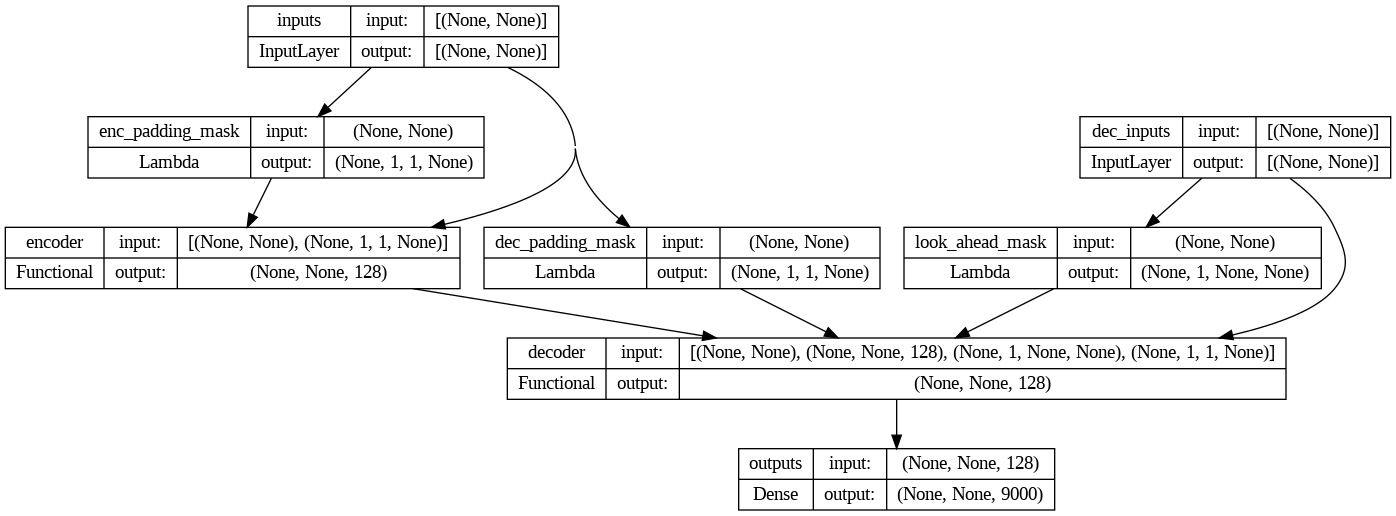

In [27]:
small_transformer = transformer(
    vocab_size = 9000,
    num_layers = 4,
    dff = 512,
    d_model = 128,
    num_heads = 4,
    dropout = 0.3,
    name="small_transformer")

tf.keras.utils.plot_model(
    small_transformer,
    show_shapes=True
)

# 손실 함수 정의 하기
- 다중분류 문제
- 크로스 엔트로피 함수로 정의  

In [28]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))  # MAX_LEGNTH 값(패딩길이) 은 나중에 정해줌

  loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')(y_true, y_pred)
        # from_logits=True   <- y_pred 가 softmax 를 거치지 않은 low digits 임을 나마냄
        # reduction='none'  : 손실을 평균내지 않고 각 토큰마다 개별손실을 리턴함.  => (batch, MAX_LENGTH-1)

  # 마스크를 적용해서 패딩위치의 손실은 0으로 제거하기 => 의미있는 토큰들의 손실값만 반영
  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)

  return tf.reduce_mean(loss)  # 토큰 손실의 평균 계산.


# 20. 학습률
- 학습률 스케줄러(Learning rate Scheduler)는 미리 학습 일정을 정해두고 그 일정에 따라 학습률이 조정되는 방법입니다.
- 트랜스포머의 경우 사용자가 정한 단계까지는 학습률을 증가시켰다가 단계에 이르면 학습률을 점차적으로 떨어트리는 방식을 사용합니다.
- 좀 더 구체적으로 봅시다. step_num(단계)이란 옵티마이저가 매개변수를 업데이트 하는 한 번의 진행 횟수를 의미합니다.
- 트랜스포머에서는 warmup_steps이라는 변수를 정하고 step_num이 warmup_steps보다 작을 경우는 학습률을 선형적으로 증가 시키고, step_num이 warmup_steps에 도달하게 되면 학습률을 step_num의 역제곱근에 따라서 감소시킵니다.
- 이를 식으로 표현하면 아래와 같습니다. warmup_steps의 값으로는 4,000을 사용하였습니다.

$$lrate = d^{-0.5}_{model} \times min(\text{step_num}^{-0.5}, \text{step_num} \times \text{warmup_steps}^{-1.5})$$

In [29]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()
    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)
    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps**-1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

Text(0.5, 0, 'Train Step')

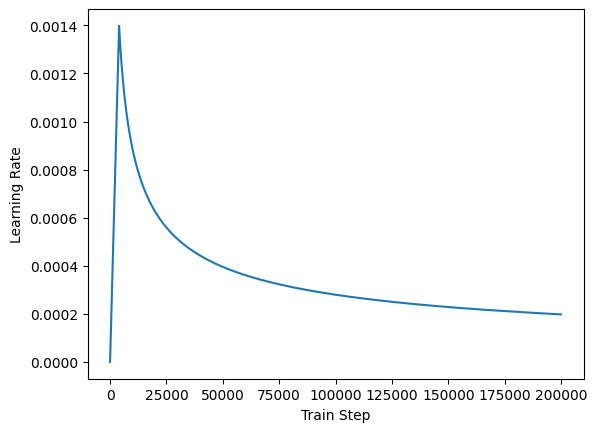

In [30]:
# 학습률의 변화를 시각화해봅시다.

sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

---
# ■ 트랜스포머를 이용한 한국어 챗봇(Transformer Chatbot Tutorial)

- 앞서 구현한 트랜스포머 코드를 사용하여 일상 대화 챗봇을 구현합니다.

- 이번 실습은 바로 이전의 트랜스포머 실습 코드를 모두 실행하였다고 가정하므로 이전 트랜스포머 실습을 진행 후에 이어서 진행해야 합니다

## 1. 데이터 로드 & 전처리

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
import time
import tensorflow_datasets as tfds  ## !!
import tensorflow as tf

In [32]:
# 챗봇 데이터를 로드하여 상위 5개의 샘플을 출력해봅시다.
urllib.request.urlretrieve("https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv", filename="ChatBotData.csv")
train_data = pd.read_csv('ChatBotData.csv')
train_data.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [33]:
print(train_data.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [34]:
# 이번 예제에서는
#  토큰화를 위해 형태소 분석기를 사용하지 않겠습니다.

# 대신, 학습기반의 토크나이저를 사용할 겁니다.

# 구두점 처리 : 제거 하지 말고,  구두점 앞에 공백을 추가하여 다른 문자들과 구분
#    '12시 땡!' -> '12시 땡 !'
#    정규표현식으로 가능!

In [35]:
questions = []
for sentence in train_data['Q']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    questions.append(sentence)

In [36]:
answers = []
for sentence in train_data['A']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    answers.append(sentence)

In [37]:
print(questions[:5])
print(answers[:5])

['12시 땡 !', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네']
['하루가 또 가네요 .', '위로해 드립니다 .', '여행은 언제나 좋죠 .', '여행은 언제나 좋죠 .', '눈살이 찌푸려지죠 .']


## 단어 사전(단어집합) 생성

In [38]:
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(questions + answers, target_vocab_size=2**13)

In [39]:
tokenizer.vocab_size

8178

In [40]:
# 위 단어집합에 <sos> 와 <eos> 토큰도 추가해야 함.

START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]

# <sos> 와 <eos> 를 고려하여 단어 사전 크기를 +2
VOCAB_SIZE = tokenizer.vocab_size + 2

In [41]:
print('시작 토큰 번호 :',START_TOKEN)
print('종료 토큰 번호 :',END_TOKEN)
print('단어 집합의 크기 :',VOCAB_SIZE)

시작 토큰 번호 : [8178]
종료 토큰 번호 : [8179]
단어 집합의 크기 : 8180


## 정수 인코딩 과 패딩

In [42]:
questions[20]

'가스비 비싼데 감기 걸리겠어'

In [43]:
tokenizer.encode(questions[20])

[5766, 611, 3509, 141, 685, 3747, 849]

In [46]:
sample_string = questions[20]

tokenized_string = tokenizer.encode(sample_string)
print('정수 인코딩:', tokenized_string)

# decode() : 정수 시퀀스 -> 텍스트 시퀀스
original_string = tokenizer.decode(tokenized_string)
print('기존 문장:', original_string)



정수 인코딩: [5766, 611, 3509, 141, 685, 3747, 849]
기존 문장: 가스비 비싼데 감기 걸리겠어


In [47]:
# 각 정수가 어떤 '서브워드' 로 매핑되는지 보자.

# 서브워드텍스트인코더는 의미있는 단위의 서브워드로 토크나이징한다. 띄어쓰기 단위 X 형태소 분석 단위 X
for ts in tokenized_string:
  print(f'{ts} ---> {tokenizer.decode([ts])}')

5766 ---> 가스
611 ---> 비 
3509 ---> 비싼
141 ---> 데 
685 ---> 감기 
3747 ---> 걸리
849 ---> 겠어


In [48]:
# 전체 데이터에 대해 정수 인코딩과 패딩

MAX_LENGTH = 40  # 패딩의 길이

# 토큰화 / 정수 인코딩 / 시작 토큰과 종료 토큰 추가 / 패딩

def tokenize_and_filter(inputs, outputs):
  tokenized_inputs, tokenized_outputs = [], []

  for (sentence1, sentence2) in zip(inputs, outputs):
    # encode(), <sos> <eos> 추가
    sentence1 = START_TOKEN + tokenizer.encode(sentence1) + END_TOKEN
    sentence2 = START_TOKEN + tokenizer.encode(sentence2) + END_TOKEN

    tokenized_inputs.append(sentence1)
    tokenized_outputs.append(sentence2)

  # 패딩
  tokenized_inputs = keras.preprocessing.sequence.pad_sequences(tokenized_inputs, maxlen=MAX_LENGTH, padding='post')
  tokenized_outputs = keras.preprocessing.sequence.pad_sequences(tokenized_outputs, maxlen=MAX_LENGTH, padding='post')

  return tokenized_inputs, tokenized_outputs


In [49]:
questions, answers = tokenize_and_filter(questions, answers)

In [50]:
print('질문 데이터의 크기(shape) :', questions.shape)
print('답변 데이터의 크기(shape) :', answers.shape)


질문 데이터의 크기(shape) : (11823, 40)
답변 데이터의 크기(shape) : (11823, 40)


## 인코더와 디코더의 입력, 그리고 레이블 만들기  

In [53]:
# 텐서플로우 dataset을 이용하여 셔플(shuffle)을 수행하되, 배치 크기로 데이터를 묶는다.
# 또한 이 과정에서 교사 강요(teacher forcing)을 사용하기 위해서 디코더의 입력과 실제값 시퀀스를 구성한다.
BATCH_SIZE = 64
BUFFER_SIZE = 20000

dataset = tf.data.Dataset.from_tensor_slices((
    {
        'inputs': questions,  # 인코더의 입력
        'dec_inputs': answers[:, :-1]  # 디코더의 입력,  마지막 토큰 제거
    },
    {
        'outputs': answers[:, 1:]  # 시작 토큰 제거.
    },
))


dataset = dataset.cache()
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)


## 트랜스포머 만들기

이제 트랜스포머를 만들어봅시다. 하이퍼파라미터를 조정하여 실제 논문의 트랜스포머보다는 작은 모델을 만듭니다.
여기서 선택한 주요 하이퍼파라미터의 값은 다음과 같습니다.

$d_{model}$ = 256

$\text{num_layers}$ = 2

$\text{num_heads}$ = 8

$d_{ff}$ = 512

In [55]:
tf.keras.backend.clear_session()

# 하이퍼파라미터
D_MODEL = 256
NUM_LAYERS = 2
NUM_HEADS = 8
DFF = 512
DROPOUT = 0.1


model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    dff=DFF,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)


(1, 8180, 256)
(1, 8180, 256)


## 옵티마이저, 컴파일

In [58]:
learning_rate = CustomSchedule(D_MODEL)

optimizer = keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9 )

def accuracy(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH -1))
  return keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])


## 학습

In [59]:
EPOCHS = 50
model.fit(dataset, epochs=EPOCHS)

Epoch 1/50
185/185 [==============================] - 113s 552ms/step - loss: 1.4584 - accuracy: 0.0230
Epoch 2/50
185/185 [==============================] - 104s 562ms/step - loss: 1.1813 - accuracy: 0.0494
Epoch 3/50
185/185 [==============================] - 102s 551ms/step - loss: 1.0027 - accuracy: 0.0508
Epoch 4/50
185/185 [==============================] - 107s 581ms/step - loss: 0.9282 - accuracy: 0.0545
Epoch 5/50
185/185 [==============================] - 105s 567ms/step - loss: 0.8723 - accuracy: 0.0574
Epoch 6/50
185/185 [==============================] - 106s 575ms/step - loss: 0.8135 - accuracy: 0.0614
Epoch 7/50
185/185 [==============================] - 106s 574ms/step - loss: 0.7486 - accuracy: 0.0673
Epoch 8/50
185/185 [==============================] - 102s 550ms/step - loss: 0.6749 - accuracy: 0.0751
Epoch 9/50
185/185 [==============================] - 100s 539ms/step - loss: 0.5931 - accuracy: 0.0840
Epoch 10/50
185/185 [==============================] - 101s 546m

## 평가하기

In [63]:
def preprocess_sentence(sentence):
  # 단어와 구두점 사이에 공백 추가.
  # ex) 12시 땡! -> 12시 땡 !
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = sentence.strip()
  return sentence

In [70]:
def evaluate(sentence):
  # 입력 문장에 대한 전처리
  sentence = preprocess_sentence(sentence)

  # 입력 문장을 정수시퀀스로 변환하고 시작 토큰과 종료 토큰을 추가
  sentence = tf.expand_dims(
      START_TOKEN + tokenizer.encode(sentence) + END_TOKEN, axis=0)

  output = tf.expand_dims(START_TOKEN, 0)

  # 디코더의 예측 시작
  for i in range(MAX_LENGTH):
    predictions = model(inputs=[sentence, output], training=False)

    # 현재 시점의 예측 단어를 받아온다.
    predictions = predictions[:, -1:, :]
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

    # 만약 현재 시점의 예측 단어가 종료 토큰이라면 예측을 중단
    if tf.equal(predicted_id, END_TOKEN[0]): break

    # 현재 시점의 예측 단어를 output(출력)에 연결한다.
    # output은 for문의 다음 루프에서 디코더의 입력이 된다.
    output = tf.concat([output, predicted_id], axis=-1)

  # 단어 예측이 모두 끝났다면 output을 리턴.
  return tf.squeeze(output, axis=0)

In [73]:
def predict(sentence):
  prediction = evaluate(sentence)

  # prediction == 디코더가 리턴한 챗봇의 대답에 해당하는 정수 시퀀스
  # tokenizer.decode()를 통해 정수 시퀀스를 문자열로 디코딩.
  predicted_sentence = tokenizer.decode(
      [i for i in prediction if i < tokenizer.vocab_size])

  print('Input: {}'.format(sentence))  # 입력문장
  print('Output: {}'.format(predicted_sentence)) # 답변(예측) 문장

  return predicted_sentence


In [74]:
output = predict("영화 볼래?")

Input: 영화 볼래?
Output: 혼자 사는 것도 나쁘지 않아요 .


In [75]:
output = predict("고민이 있어")

Input: 고민이 있어
Output: �여에 �괜찮아요 .


In [76]:
output = predict("너무 당황스러워")

Input: 너무 당황스러워
Output: 이제 무슨 일이 있었나봐요 .


In [77]:
output = predict("카페 갈래?")

Input: 카페 갈래?
Output: 


In [78]:
output = predict("집에 가고 싶다")

Input: 집에 가고 싶다
Output: 집이 최고죠 .
